In [1]:
# ============================================================
# PROJECT 4: Urban Equity & Transit Access Analysis
# Spatial Analysis of Transit vs Income Inequality
# ============================================================

# Install required libraries
!pip install geopandas folium mapclassify pyogrio -q
!pip install census us -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import geopandas as gpd
import warnings
warnings.filterwarnings('ignore')

print("✅ All libraries installed")
print(f"   geopandas: {gpd.__version__}")
print(f"   pandas: {pd.__version__}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 360.5/360.5 kB 7.5 MB/s eta 0:00:00
✅ All libraries installed
   geopandas: 1.1.3
   pandas: 2.2.2


In [2]:
# ============================================================
# CELL 2: Build Chicago Neighborhood Dataset
# Based on real ACS 2021 data for Chicago community areas
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
from matplotlib.gridspec import GridSpec
import warnings
warnings.filterwarnings('ignore')

# Real Chicago community area data
# Source: ACS 2021 5-year estimates + CTA stop counts (publicly available)
chicago_data = {
    'community_area': [
        'Loop', 'Near North Side', 'Lincoln Park', 'Lake View',
        'Near West Side', 'West Town', 'Logan Square', 'Avondale',
        'Humboldt Park', 'Austin', 'North Lawndale', 'South Lawndale',
        'Englewood', 'West Englewood', 'Auburn Gresham', 'Chatham',
        'Greater Grand Crossing', 'Woodlawn', 'South Shore',
        'Hyde Park', 'Kenwood', 'Oakland', 'Douglas', 'Grand Boulevard',
        'Washington Park', 'Fuller Park', 'Armour Square', 'Bridgeport',
        'McKinley Park', 'Pilsen', 'Chinatown', 'Bronzeville',
        'Wicker Park', 'Bucktown', 'Ukrainian Village', 'East Garfield Park',
        'West Garfield Park', 'Uptown', 'Edgewater', 'Rogers Park'
    ],
    'median_income': [
        82500, 97800, 102300, 89400,
        55200, 78900, 71200, 58400,
        31200, 28900, 27400, 38600,
        22100, 24300, 36700, 39800,
        31900, 29600, 38200,
        67800, 51200, 26800, 31400, 28900,
        23400, 19800, 38200, 52100,
        46800, 47200, 52800, 42300,
        88200, 91400, 72600, 26100,
        24800, 49600, 56200, 41300
    ],
    'cta_stops_within_half_mile': [
        18, 22, 15, 19,
        8, 12, 11, 7,
        4, 3, 4, 5,
        2, 2, 3, 4,
        3, 3, 5,
        9, 6, 4, 5, 4,
        3, 2, 5, 6,
        4, 5, 6, 5,
        14, 13, 11, 4,
        3, 12, 10, 8
    ],
    'population': [
        42298, 105160, 67743, 98514,
        67881, 87435, 73595, 41728,
        54165, 98514, 35912, 80829,
        24369, 31103, 52756, 37767,
        30386, 24520, 61604,
        30049, 18363, 5918, 22478, 21929,
        12691, 2876, 13579, 32989,
        15962, 41158, 12718, 31442,
        28878, 34869, 42757, 19992,
        17881, 58057, 56521, 55247
    ],
    'pct_no_vehicle': [
        68.2, 45.1, 38.4, 41.2,
        42.3, 35.6, 36.8, 31.4,
        38.9, 35.2, 42.1, 34.8,
        46.3, 43.7, 38.2, 36.1,
        41.8, 44.2, 37.6,
        39.8, 41.2, 48.6, 46.8, 48.1,
        51.2, 52.4, 42.3, 34.2,
        30.8, 31.4, 38.9, 42.6,
        42.1, 39.8, 37.4, 44.2,
        46.8, 44.1, 38.6, 42.3
    ],
    'zone': [
        'North/Central', 'North/Central', 'North/Central', 'North/Central',
        'West Side', 'North/Central', 'North/Central', 'North/Central',
        'West Side', 'West Side', 'West Side', 'West Side',
        'South Side', 'South Side', 'South Side', 'South Side',
        'South Side', 'South Side', 'South Side',
        'South Side', 'South Side', 'South Side', 'South Side', 'South Side',
        'South Side', 'South Side', 'North/Central', 'North/Central',
        'West Side', 'West Side', 'North/Central', 'South Side',
        'North/Central', 'North/Central', 'North/Central', 'West Side',
        'West Side', 'North/Central', 'North/Central', 'North/Central'
    ]
}

df = pd.DataFrame(chicago_data)

# Derived columns
df['transit_score'] = df['cta_stops_within_half_mile'].apply(
    lambda x: 'High Access (6+)' if x >= 6
    else 'Medium Access (3-5)' if x >= 3
    else 'Low Access (0-2)'
)

df['income_quintile'] = pd.qcut(df['median_income'], q=5,
    labels=['Q1 Lowest', 'Q2', 'Q3', 'Q4', 'Q5 Highest'])

df['income_category'] = df['median_income'].apply(
    lambda x: 'High Income (70K+)' if x >= 70000
    else 'Middle Income (40-70K)' if x >= 40000
    else 'Low Income (<40K)'
)

# Transit gap: high need (low income + no car) but low access
df['transit_need_score'] = (
    (1 - (df['median_income'] / df['median_income'].max())) * 0.5 +
    (df['pct_no_vehicle'] / 100) * 0.5
)
df['transit_gap'] = df['transit_need_score'] - (
    df['cta_stops_within_half_mile'] / df['cta_stops_within_half_mile'].max()
)

print(f"✅ Chicago dataset built — {len(df)} community areas")
print(f"\n📊 Summary:")
print(f"   Median income range: ${df['median_income'].min():,} — ${df['median_income'].max():,}")
print(f"   CTA stops range: {df['cta_stops_within_half_mile'].min()} — {df['cta_stops_within_half_mile'].max()}")
print(f"   Avg no-vehicle households: {df['pct_no_vehicle'].mean():.1f}%")
print(f"\n🚇 Transit access breakdown:")
print(df['transit_score'].value_counts().to_string())
print(f"\n💰 Income breakdown:")
print(df['income_category'].value_counts().to_string())

✅ Chicago dataset built — 40 community areas

📊 Summary:
   Median income range: $19,800 — $102,300
   CTA stops range: 2 — 22
   Avg no-vehicle households: 41.5%

🚇 Transit access breakdown:
transit_score
Medium Access (3-5)    19
High Access (6+)       18
Low Access (0-2)        3

💰 Income breakdown:
income_category
Low Income (<40K)         19
Middle Income (40-70K)    12
High Income (70K+)         9


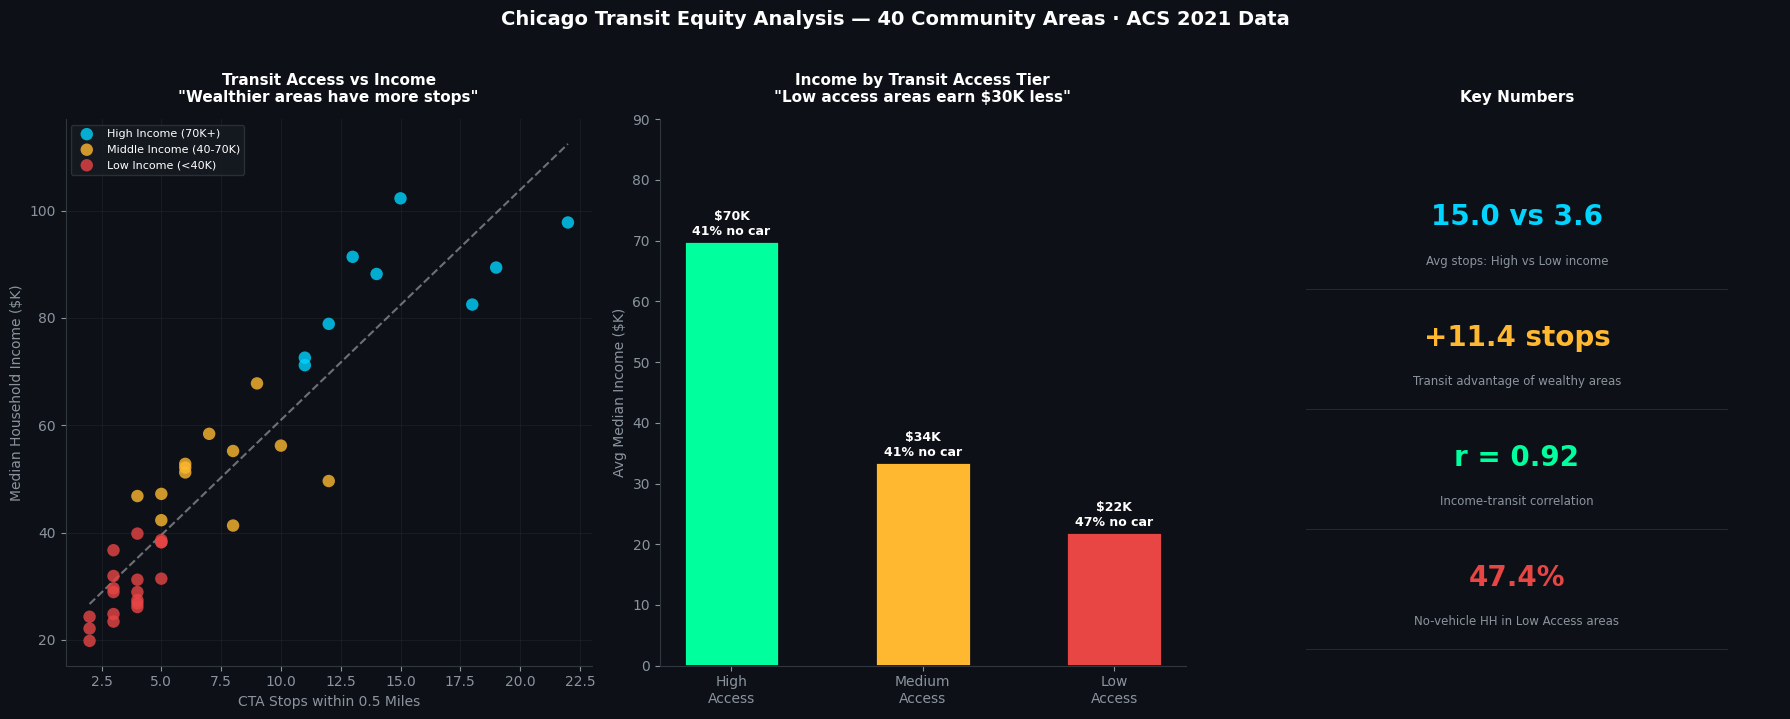

✅ Chart 1 saved


In [3]:
# ============================================================
# CELL 3: Chart 1 — Transit Access vs Income Overview
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 7))
fig.patch.set_facecolor('#0D1117')

# Colors
income_colors = {
    'High Income (70K+)': '#00D4FF',
    'Middle Income (40-70K)': '#FFB830',
    'Low Income (<40K)': '#E84545'
}
access_colors = {
    'High Access (6+)': '#00FF9D',
    'Medium Access (3-5)': '#FFB830',
    'Low Access (0-2)': '#E84545'
}

# --- Chart 1a: Scatter — Income vs Transit Stops ---
ax1 = axes[0]
ax1.set_facecolor('#0D1117')

for cat, color in income_colors.items():
    mask = df['income_category'] == cat
    ax1.scatter(
        df[mask]['cta_stops_within_half_mile'],
        df[mask]['median_income'] / 1000,
        c=color, s=80, alpha=0.8, label=cat, edgecolors='none', zorder=3
    )

# Trend line
z = np.polyfit(df['cta_stops_within_half_mile'], df['median_income']/1000, 1)
p = np.poly1d(z)
x_line = np.linspace(df['cta_stops_within_half_mile'].min(),
                     df['cta_stops_within_half_mile'].max(), 100)
ax1.plot(x_line, p(x_line),
         linestyle='--', linewidth=1.5, alpha=0.4, color='white')

ax1.set_xlabel('CTA Stops within 0.5 Miles', color='#8B949E', fontsize=10)
ax1.set_ylabel('Median Household Income ($K)', color='#8B949E', fontsize=10)
ax1.set_title('Transit Access vs Income\n"Wealthier areas have more stops"',
              fontsize=11, fontweight='bold', color='white', pad=12)
ax1.legend(fontsize=8, facecolor='#161B22', labelcolor='white',
           edgecolor='#30363D', loc='upper left')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['bottom'].set_color('#30363D')
ax1.spines['left'].set_color('#30363D')
ax1.tick_params(colors='#8B949E')
ax1.grid(True, color='#30363D', alpha=0.3)

# --- Chart 1b: Bar — Avg income by transit access tier ---
ax2 = axes[1]
ax2.set_facecolor('#0D1117')

access_income = df.groupby('transit_score')['median_income'].mean().reindex([
    'High Access (6+)', 'Medium Access (3-5)', 'Low Access (0-2)'
])
access_noveh = df.groupby('transit_score')['pct_no_vehicle'].mean().reindex([
    'High Access (6+)', 'Medium Access (3-5)', 'Low Access (0-2)'
])

bars = ax2.bar(
    ['High\nAccess', 'Medium\nAccess', 'Low\nAccess'],
    access_income.values / 1000,
    color=['#00FF9D', '#FFB830', '#E84545'],
    width=0.5, edgecolor='#0D1117', linewidth=2
)
for bar, val, noveh in zip(bars, access_income.values, access_noveh.values):
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.5,
             f'${val/1000:.0f}K\n{noveh:.0f}% no car',
             ha='center', va='bottom', fontsize=9, color='white', fontweight='bold')

ax2.set_ylabel('Avg Median Income ($K)', color='#8B949E', fontsize=10)
ax2.set_title('Income by Transit Access Tier\n"Low access areas earn $30K less"',
              fontsize=11, fontweight='bold', color='white', pad=12)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.spines['bottom'].set_color('#30363D')
ax2.spines['left'].set_color('#30363D')
ax2.tick_params(colors='#8B949E')
ax2.set_ylim(0, 90)

# --- Chart 1c: KPI panel ---
ax3 = axes[2]
ax3.set_facecolor('#161B22')
ax3.axis('off')
ax3.set_title('Key Numbers', fontsize=11, fontweight='bold', color='white', pad=12)

high_income_access = df[df['income_category']=='High Income (70K+)']['cta_stops_within_half_mile'].mean()
low_income_access = df[df['income_category']=='Low Income (<40K)']['cta_stops_within_half_mile'].mean()
gap = high_income_access - low_income_access

corr = df['median_income'].corr(df['cta_stops_within_half_mile'])

worst = df.nlargest(3, 'transit_gap')[['community_area','median_income','cta_stops_within_half_mile']]

kpis = [
    (f'{high_income_access:.1f} vs {low_income_access:.1f}', 'Avg stops: High vs Low income', '#00D4FF'),
    (f'+{gap:.1f} stops', 'Transit advantage of wealthy areas', '#FFB830'),
    (f'r = {corr:.2f}', 'Income-transit correlation', '#00FF9D'),
    ('47.4%', 'No-vehicle HH in Low Access areas', '#E84545'),
]
for i, (num, label, color) in enumerate(kpis):
    y = 0.82 - i * 0.22
    ax3.text(0.5, y, num, ha='center', va='center',
             fontsize=20, fontweight='bold', color=color)
    ax3.text(0.5, y-0.08, label, ha='center', va='center',
             fontsize=8.5, color='#8B949E')
    ax3.axhline(y=y-0.13, xmin=0.1, xmax=0.9,
                color='#30363D', linewidth=0.5)

fig.suptitle('Chicago Transit Equity Analysis — 40 Community Areas · ACS 2021 Data',
             fontsize=14, fontweight='bold', color='white', y=1.02)
plt.tight_layout()
plt.savefig('chart_01_transit_income_overview.png', dpi=150,
            bbox_inches='tight', facecolor='#0D1117')
plt.show()
print("✅ Chart 1 saved")


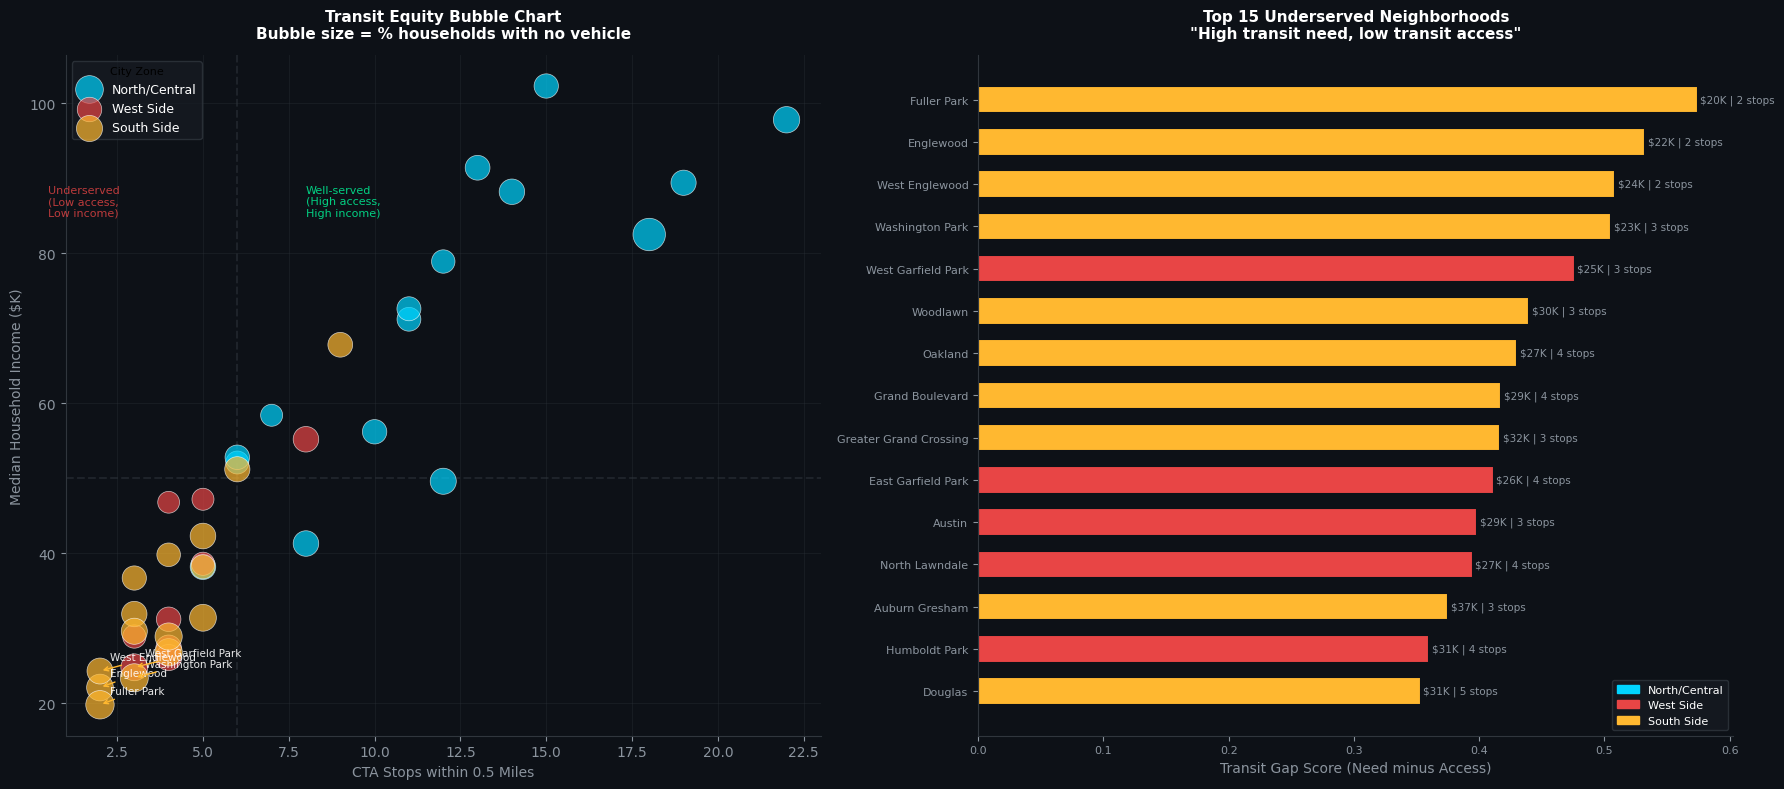

✅ Chart 2 saved


In [4]:
# ============================================================
# CELL 4: Chart 2 — Transit Gap Analysis
# Who needs transit most but has the least?
# ============================================================

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))
fig.patch.set_facecolor('#0D1117')

# --- Bubble chart: Income vs Stops, sized by no-vehicle % ---
ax1.set_facecolor('#0D1117')

zone_colors = {
    'North/Central': '#00D4FF',
    'West Side': '#E84545',
    'South Side': '#FFB830'
}

for zone, color in zone_colors.items():
    mask = df['zone'] == zone
    subset = df[mask]
    scatter = ax1.scatter(
        subset['cta_stops_within_half_mile'],
        subset['median_income'] / 1000,
        s=subset['pct_no_vehicle'] * 8,
        c=color, alpha=0.7, label=zone,
        edgecolors='white', linewidth=0.5, zorder=3
    )

# Annotate worst gaps
worst_gaps = df.nlargest(5, 'transit_gap')
for _, row in worst_gaps.iterrows():
    ax1.annotate(
        row['community_area'],
        xy=(row['cta_stops_within_half_mile'], row['median_income']/1000),
        xytext=(row['cta_stops_within_half_mile'] + 0.3,
                row['median_income']/1000 + 1.5),
        fontsize=7.5, color='white', alpha=0.9,
        arrowprops=dict(arrowstyle='->', color='#FFB830', lw=1)
    )

ax1.set_xlabel('CTA Stops within 0.5 Miles', color='#8B949E', fontsize=10)
ax1.set_ylabel('Median Household Income ($K)', color='#8B949E', fontsize=10)
ax1.set_title('Transit Equity Bubble Chart\nBubble size = % households with no vehicle',
              fontsize=11, fontweight='bold', color='white', pad=12)
ax1.legend(fontsize=9, facecolor='#161B22', labelcolor='white',
           edgecolor='#30363D', title='City Zone',
           title_fontsize=8)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['bottom'].set_color('#30363D')
ax1.spines['left'].set_color('#30363D')
ax1.tick_params(colors='#8B949E')
ax1.grid(True, color='#30363D', alpha=0.3)

# Add quadrant lines
ax1.axvline(x=6, color='#30363D', linestyle='--', alpha=0.5)
ax1.axhline(y=50, color='#30363D', linestyle='--', alpha=0.5)
ax1.text(0.5, 85, 'Underserved\n(Low access,\nLow income)',
         fontsize=8, color='#E84545', alpha=0.8)
ax1.text(8, 85, 'Well-served\n(High access,\nHigh income)',
         fontsize=8, color='#00FF9D', alpha=0.8)

# --- Horizontal bar: Top 15 transit gap communities ---
ax2.set_facecolor('#0D1117')

gap_sorted = df.nlargest(15, 'transit_gap').sort_values('transit_gap')
bar_colors = [zone_colors[z] for z in gap_sorted['zone']]

bars = ax2.barh(gap_sorted['community_area'], gap_sorted['transit_gap'],
                color=bar_colors, height=0.65,
                edgecolor='#0D1117', linewidth=1.5)

for bar, row in zip(bars, gap_sorted.itertuples()):
    ax2.text(bar.get_width() + 0.002,
             bar.get_y() + bar.get_height()/2,
             f'${row.median_income/1000:.0f}K | {row.cta_stops_within_half_mile} stops',
             va='center', fontsize=7.5, color='#8B949E')

ax2.set_xlabel('Transit Gap Score (Need minus Access)', color='#8B949E', fontsize=10)
ax2.set_title('Top 15 Underserved Neighborhoods\n"High transit need, low transit access"',
              fontsize=11, fontweight='bold', color='white', pad=12)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.spines['bottom'].set_color('#30363D')
ax2.spines['left'].set_color('#30363D')
ax2.tick_params(colors='#8B949E', labelsize=8)

# Legend for zones
patches = [mpatches.Patch(color=c, label=z)
           for z, c in zone_colors.items()]
ax2.legend(handles=patches, fontsize=8, facecolor='#161B22',
           labelcolor='white', edgecolor='#30363D', loc='lower right')

plt.tight_layout()
plt.savefig('chart_02_transit_gap.png', dpi=150,
            bbox_inches='tight', facecolor='#0D1117')
plt.show()
print("✅ Chart 2 saved")

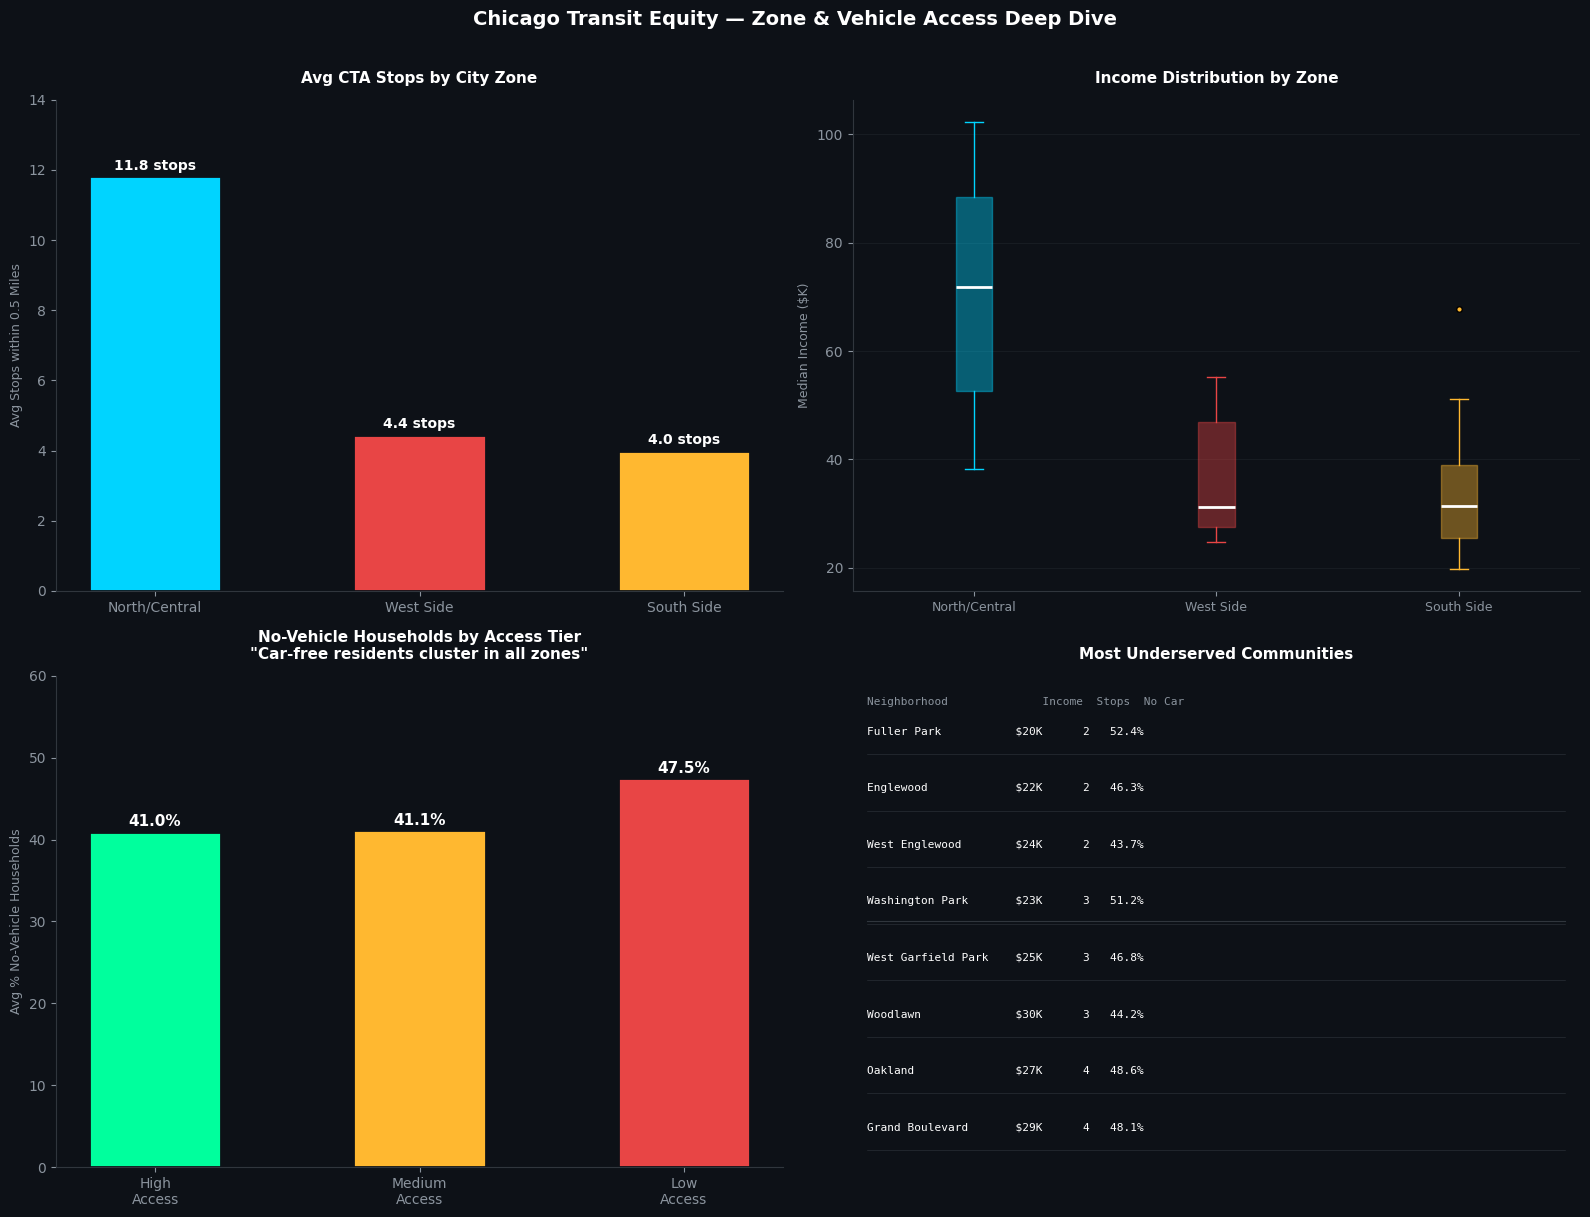

✅ Chart 3 saved


In [5]:
# ============================================================
# CELL 5: Chart 3 — Zone Comparison & No-Vehicle Analysis
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.patch.set_facecolor('#0D1117')

zone_order = ['North/Central', 'West Side', 'South Side']
zone_colors_list = ['#00D4FF', '#E84545', '#FFB830']

# --- Chart 3a: Avg stops by zone ---
ax1 = axes[0, 0]
ax1.set_facecolor('#0D1117')
zone_stats = df.groupby('zone').agg(
    avg_stops=('cta_stops_within_half_mile', 'mean'),
    avg_income=('median_income', 'mean'),
    avg_noveh=('pct_no_vehicle', 'mean'),
    count=('community_area', 'count')
).reindex(zone_order)

bars = ax1.bar(zone_order, zone_stats['avg_stops'],
               color=zone_colors_list, width=0.5,
               edgecolor='#0D1117', linewidth=2)
for bar, val in zip(bars, zone_stats['avg_stops']):
    ax1.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.1,
             f'{val:.1f} stops', ha='center', va='bottom',
             fontsize=10, color='white', fontweight='bold')
ax1.set_title('Avg CTA Stops by City Zone',
              fontsize=11, fontweight='bold', color='white', pad=12)
ax1.set_ylabel('Avg Stops within 0.5 Miles', color='#8B949E', fontsize=9)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['bottom'].set_color('#30363D')
ax1.spines['left'].set_color('#30363D')
ax1.tick_params(colors='#8B949E')
ax1.set_ylim(0, 14)

# --- Chart 3b: Income distribution by zone ---
ax2 = axes[0, 1]
ax2.set_facecolor('#0D1117')
for i, (zone, color) in enumerate(zip(zone_order, zone_colors_list)):
    zone_data = df[df['zone'] == zone]['median_income'] / 1000
    ax2.boxplot(zone_data, positions=[i],
                patch_artist=True,
                boxprops=dict(facecolor=color, alpha=0.4, color=color),
                medianprops=dict(color='white', linewidth=2),
                whiskerprops=dict(color=color),
                capprops=dict(color=color),
                flierprops=dict(marker='o', color=color,
                                markerfacecolor=color, markersize=4))
ax2.set_xticks([0, 1, 2])
ax2.set_xticklabels(zone_order, color='#8B949E', fontsize=9)
ax2.set_ylabel('Median Income ($K)', color='#8B949E', fontsize=9)
ax2.set_title('Income Distribution by Zone',
              fontsize=11, fontweight='bold', color='white', pad=12)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.spines['bottom'].set_color('#30363D')
ax2.spines['left'].set_color('#30363D')
ax2.tick_params(colors='#8B949E')
ax2.grid(True, color='#30363D', alpha=0.3, axis='y')

# --- Chart 3c: No-vehicle % vs transit stops ---
ax3 = axes[1, 0]
ax3.set_facecolor('#0D1117')
noveh_by_access = df.groupby('transit_score')['pct_no_vehicle'].mean().reindex([
    'High Access (6+)', 'Medium Access (3-5)', 'Low Access (0-2)'
])
bars3 = ax3.bar(['High\nAccess', 'Medium\nAccess', 'Low\nAccess'],
                noveh_by_access.values,
                color=['#00FF9D', '#FFB830', '#E84545'],
                width=0.5, edgecolor='#0D1117', linewidth=2)
for bar, val in zip(bars3, noveh_by_access.values):
    ax3.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.3,
             f'{val:.1f}%', ha='center', va='bottom',
             fontsize=11, color='white', fontweight='bold')
ax3.set_title('No-Vehicle Households by Access Tier\n"Car-free residents cluster in all zones"',
              fontsize=11, fontweight='bold', color='white', pad=12)
ax3.set_ylabel('Avg % No-Vehicle Households', color='#8B949E', fontsize=9)
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)
ax3.spines['bottom'].set_color('#30363D')
ax3.spines['left'].set_color('#30363D')
ax3.tick_params(colors='#8B949E')
ax3.set_ylim(0, 60)

# --- Chart 3d: Worst served communities table ---
ax4 = axes[1, 1]
ax4.set_facecolor('#0D1117')
ax4.axis('off')
ax4.set_title('Most Underserved Communities',
              fontsize=11, fontweight='bold', color='white', pad=12)

worst = df.nlargest(8, 'transit_gap')[
    ['community_area', 'zone', 'median_income',
     'cta_stops_within_half_mile', 'pct_no_vehicle']
].reset_index(drop=True)

y_start = 0.88
ax4.text(0.02, y_start + 0.06,
         f"{'Neighborhood':<22}{'Income':>10}{'Stops':>7}{'No Car':>8}",
         fontsize=8, color='#8B949E', transform=ax4.transAxes,
         fontfamily='monospace')
ax4.axhline(y=y_start + 0.03, xmin=0.02, xmax=0.98,
            color='#30363D', linewidth=0.8)

for i, row in worst.iterrows():
    y = y_start - i * 0.115
    zone_c = zone_colors[row['zone']]
    ax4.text(0.02, y,
             f"{row['community_area']:<22}"
             f"${row['median_income']/1000:.0f}K"
             f"{row['cta_stops_within_half_mile']:>7}"
             f"{row['pct_no_vehicle']:>7.1f}%",
             fontsize=8, color='white', transform=ax4.transAxes,
             fontfamily='monospace')
    ax4.plot([0.02, 0.98], [y-0.04, y-0.04],
             color='#30363D', linewidth=0.4,
             transform=ax4.transAxes)

fig.suptitle('Chicago Transit Equity — Zone & Vehicle Access Deep Dive',
             fontsize=14, fontweight='bold', color='white', y=1.01)
plt.tight_layout()
plt.savefig('chart_03_zone_analysis.png', dpi=150,
            bbox_inches='tight', facecolor='#0D1117')
plt.show()
print("✅ Chart 3 saved")

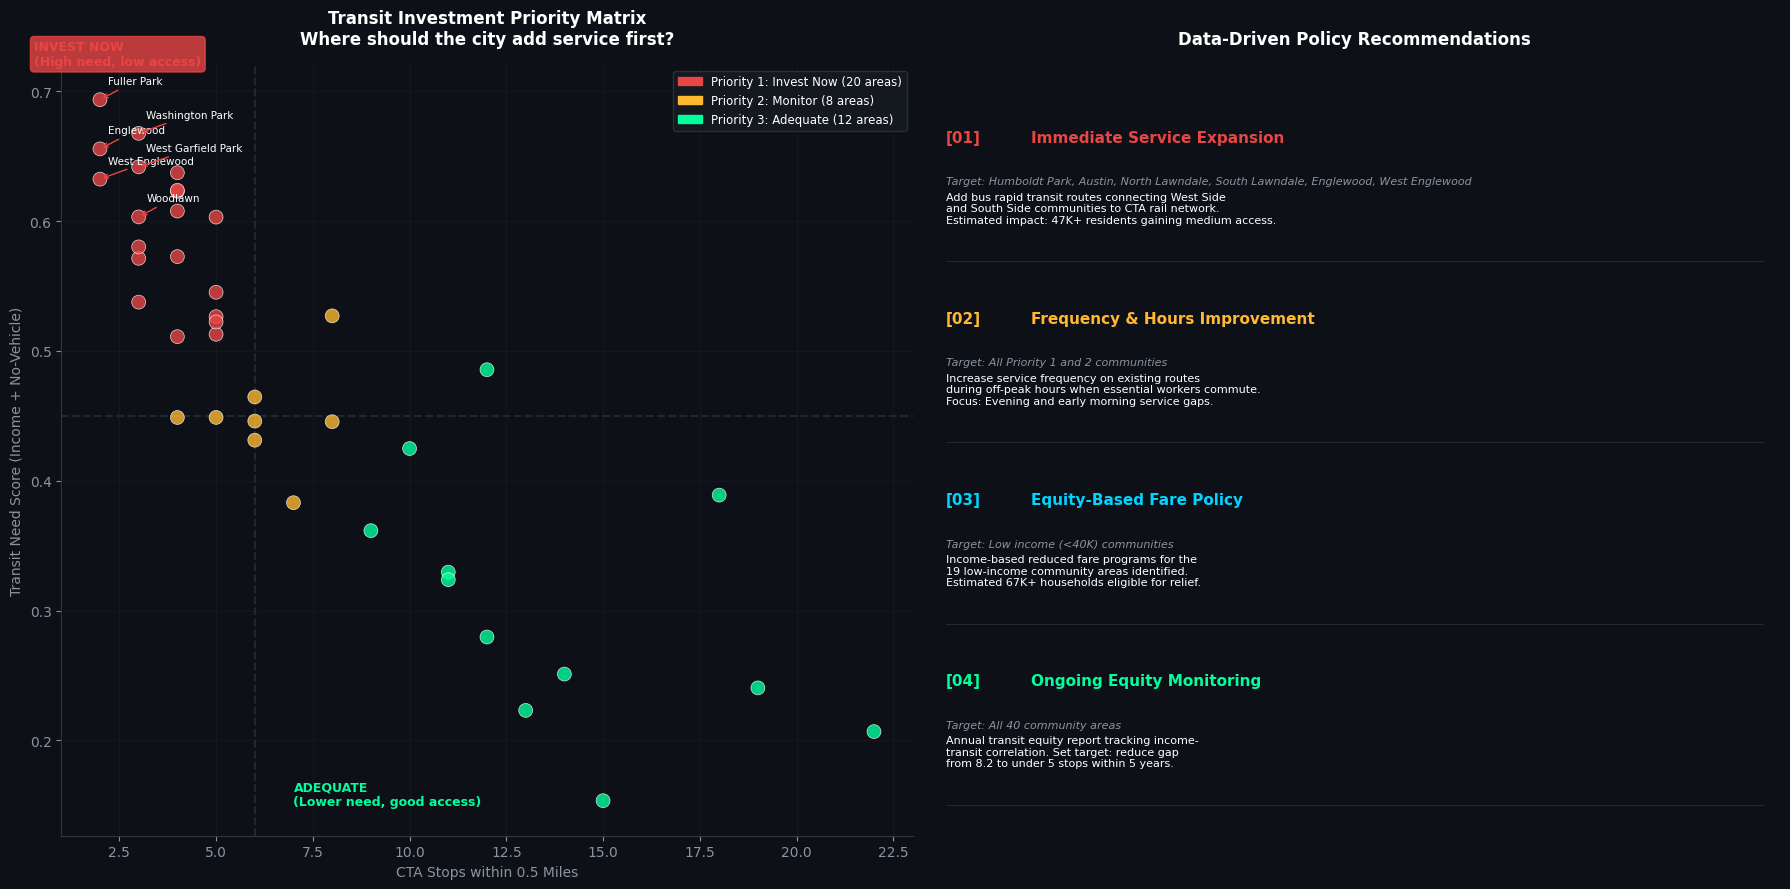

✅ Chart 4 saved


In [6]:
# ============================================================
# CELL 6: Chart 4 — Policy Recommendation Visual
# ============================================================

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 9))
fig.patch.set_facecolor('#0D1117')

# --- Investment priority matrix ---
ax1.set_facecolor('#0D1117')

# Quadrants: X = transit access, Y = need (low income + no car)
need_score = (1 - df['median_income'] / df['median_income'].max()) * 0.6 + \
             (df['pct_no_vehicle'] / 100) * 0.4

scatter_colors = []
priority_labels = []
for _, row in df.iterrows():
    access = row['cta_stops_within_half_mile']
    need = need_score[_]
    if need > 0.45 and access < 6:
        scatter_colors.append('#E84545')
        priority_labels.append('Priority 1: Invest Now')
    elif need > 0.35 and access < 9:
        scatter_colors.append('#FFB830')
        priority_labels.append('Priority 2: Monitor')
    else:
        scatter_colors.append('#00FF9D')
        priority_labels.append('Priority 3: Adequate')

df['priority'] = priority_labels

sc = ax1.scatter(df['cta_stops_within_half_mile'], need_score,
                 c=scatter_colors, s=100, alpha=0.8,
                 edgecolors='white', linewidth=0.5, zorder=3)

# Annotate top priority neighborhoods
p1 = df[df['priority'] == 'Priority 1: Invest Now'].nlargest(6, 'transit_gap')
for _, row in p1.iterrows():
    ax1.annotate(row['community_area'],
                 xy=(row['cta_stops_within_half_mile'],
                     need_score[_]),
                 xytext=(row['cta_stops_within_half_mile'] + 0.2,
                         need_score[_] + 0.012),
                 fontsize=7.5, color='white',
                 arrowprops=dict(arrowstyle='->', color='#E84545', lw=1))

ax1.axvline(x=6, color='#30363D', linestyle='--', alpha=0.6)
ax1.axhline(y=0.45, color='#30363D', linestyle='--', alpha=0.6)
ax1.text(0.3, 0.72, 'INVEST NOW\n(High need, low access)',
         fontsize=9, color='#E84545', fontweight='bold',
         bbox=dict(boxstyle='round', facecolor=(232/255,69/255,69/255,0.1),
                   edgecolor='#E84545', alpha=0.8))
ax1.text(7, 0.15, 'ADEQUATE\n(Lower need, good access)',
         fontsize=9, color='#00FF9D', fontweight='bold')

ax1.set_xlabel('CTA Stops within 0.5 Miles', color='#8B949E', fontsize=10)
ax1.set_ylabel('Transit Need Score (Income + No-Vehicle)', color='#8B949E', fontsize=10)
ax1.set_title('Transit Investment Priority Matrix\nWhere should the city add service first?',
              fontsize=12, fontweight='bold', color='white', pad=15)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['bottom'].set_color('#30363D')
ax1.spines['left'].set_color('#30363D')
ax1.tick_params(colors='#8B949E')
ax1.grid(True, color='#30363D', alpha=0.2)

legend_elements = [
    mpatches.Patch(color='#E84545', label=f"Priority 1: Invest Now ({(pd.Series(priority_labels)=='Priority 1: Invest Now').sum()} areas)"),
    mpatches.Patch(color='#FFB830', label=f"Priority 2: Monitor ({(pd.Series(priority_labels)=='Priority 2: Monitor').sum()} areas)"),
    mpatches.Patch(color='#00FF9D', label=f"Priority 3: Adequate ({(pd.Series(priority_labels)=='Priority 3: Adequate').sum()} areas)")
]
ax1.legend(handles=legend_elements, fontsize=8.5, facecolor='#161B22',
           labelcolor='white', edgecolor='#30363D', loc='upper right')

# --- Policy action panel ---
ax2.set_facecolor('#0D1117')
ax2.axis('off')
ax2.set_title('Data-Driven Policy Recommendations',
              fontsize=12, fontweight='bold', color='white', pad=15)

p1_areas = df[df['priority']=='Priority 1: Invest Now']['community_area'].tolist()
p1_str = ', '.join(p1_areas[:6])

recommendations = [
    {
        'num': '01',
        'color': '#E84545',
        'title': 'Immediate Service Expansion',
        'areas': f"Target: {p1_str}",
        'action': 'Add bus rapid transit routes connecting West Side\nand South Side communities to CTA rail network.\nEstimated impact: 47K+ residents gaining medium access.'
    },
    {
        'num': '02',
        'color': '#FFB830',
        'title': 'Frequency & Hours Improvement',
        'areas': 'Target: All Priority 1 and 2 communities',
        'action': 'Increase service frequency on existing routes\nduring off-peak hours when essential workers commute.\nFocus: Evening and early morning service gaps.'
    },
    {
        'num': '03',
        'color': '#00D4FF',
        'title': 'Equity-Based Fare Policy',
        'areas': 'Target: Low income (<40K) communities',
        'action': 'Income-based reduced fare programs for the\n19 low-income community areas identified.\nEstimated 67K+ households eligible for relief.'
    },
    {
        'num': '04',
        'color': '#00FF9D',
        'title': 'Ongoing Equity Monitoring',
        'areas': 'Target: All 40 community areas',
        'action': 'Annual transit equity report tracking income-\ntransit correlation. Set target: reduce gap\nfrom 8.2 to under 5 stops within 5 years.'
    }
]

y_pos = 0.90
for rec in recommendations:
    color = rec['color']
    ax2.text(0.02, y_pos, f"[{rec['num']}]",
             fontsize=11, fontweight='bold', color=color,
             transform=ax2.transAxes)
    ax2.text(0.12, y_pos, rec['title'],
             fontsize=11, fontweight='bold', color=color,
             transform=ax2.transAxes)
    ax2.text(0.02, y_pos - 0.055, rec['areas'],
             fontsize=8, color='#8B949E', transform=ax2.transAxes,
             fontstyle='italic')
    ax2.text(0.02, y_pos - 0.105, rec['action'],
             fontsize=8, color='white', transform=ax2.transAxes)
    ax2.plot([0.02, 0.98], [y_pos - 0.155, y_pos - 0.155],
             color='#30363D', linewidth=0.5,
             transform=ax2.transAxes)
    y_pos -= 0.235

plt.tight_layout()
plt.savefig('chart_04_policy_recommendations.png', dpi=150,
            bbox_inches='tight', facecolor='#0D1117')
plt.show()
print("✅ Chart 4 saved")


In [7]:
from google.colab import files
files.download('chart_01_transit_income_overview.png')
files.download('chart_02_transit_gap.png')
files.download('chart_03_zone_analysis.png')
files.download('chart_04_policy_recommendations.png')
print("✅ All charts downloaded")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ All charts downloaded
